In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

ROOT = r'C:\Users\Lenovo\Desktop\mineracao_midia_v2'
os.chdir(ROOT)

# Carregar dados normalizados
X = np.load('dados/X_scaled_v2.npy')
df_model = pd.read_csv('dados/df_clusters_v2.csv', sep=';')

print(f'Dados carregados: {X.shape}')
print('✅ Pronto!')

Dados carregados: (25233, 8)
✅ Pronto!


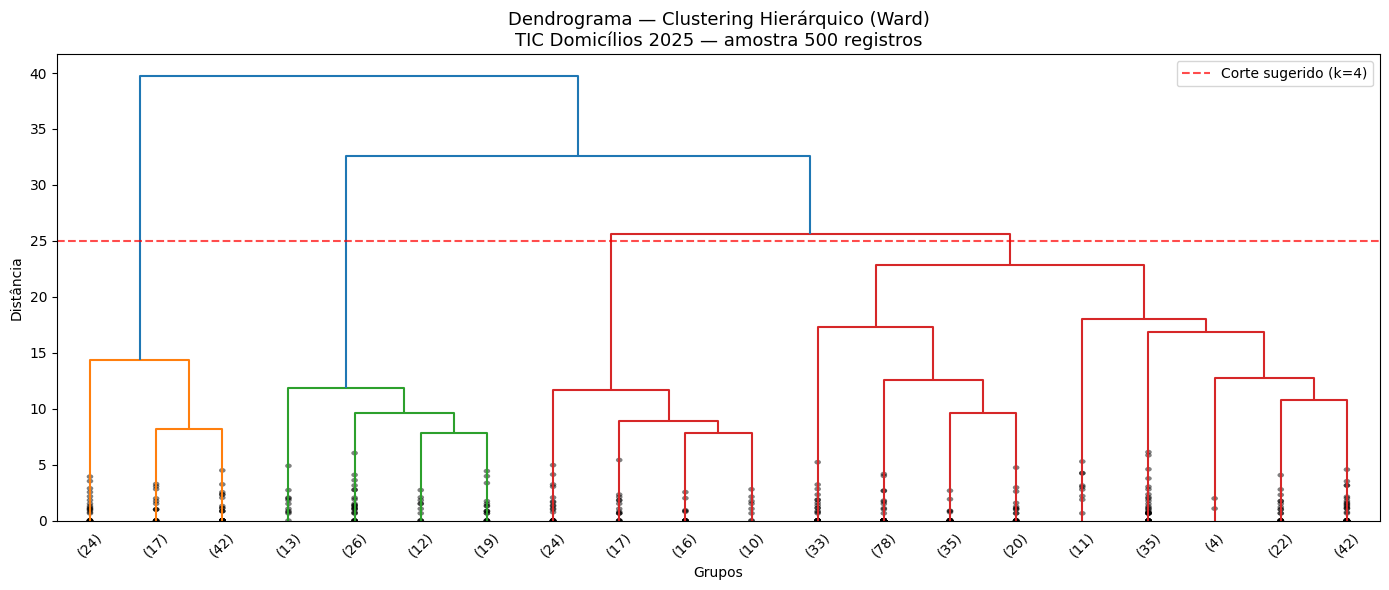

✅ Dendrograma salvo!


In [3]:
# ════════════════════════════════════════════════════
# DENDROGRAMA — amostra de 500 registros
# (usar todos os 25k seria lento demais)
# ════════════════════════════════════════════════════
np.random.seed(42)
idx = np.random.choice(len(X), 500, replace=False)
X_amostra = X[idx]

# Calcular linkage
Z = linkage(X_amostra, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(Z,
           truncate_mode='lastp',
           p=20,
           leaf_rotation=45,
           leaf_font_size=10,
           show_contracted=True)
plt.title('Dendrograma — Clustering Hierárquico (Ward)\nTIC Domicílios 2025 — amostra 500 registros', fontsize=13)
plt.xlabel('Grupos')
plt.ylabel('Distância')
plt.axhline(y=25, color='red', linestyle='--', alpha=0.7, label='Corte sugerido (k=4)')
plt.legend()
plt.tight_layout()
plt.savefig('graficos/dendrograma.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Dendrograma salvo!')

Silhouette Score — Hierárquico: 0.285
Silhouette Score — K-Means:     0.294

Diferença: 0.009

Tamanho dos clusters (Hierárquico):
0    13653
1     4752
2     3338
3     3490
Name: count, dtype: int64

Perfil médio por cluster (Hierárquico):
            tem_tv  tem_radio  tem_internet  usa_celular_net  renda  \
cluster_hc                                                            
0             1.16       0.39          0.99             0.87   2.29   
1             0.85       0.49          0.01             0.02   1.40   
2             1.56       0.53          0.98             0.95   2.97   
3             1.03       0.45          1.00             0.87   1.75   

            escolaridade  area  
cluster_hc                      
0                   3.12  1.01  
1                   2.20  1.28  
2                   3.58  1.13  
3                   2.60  2.00  


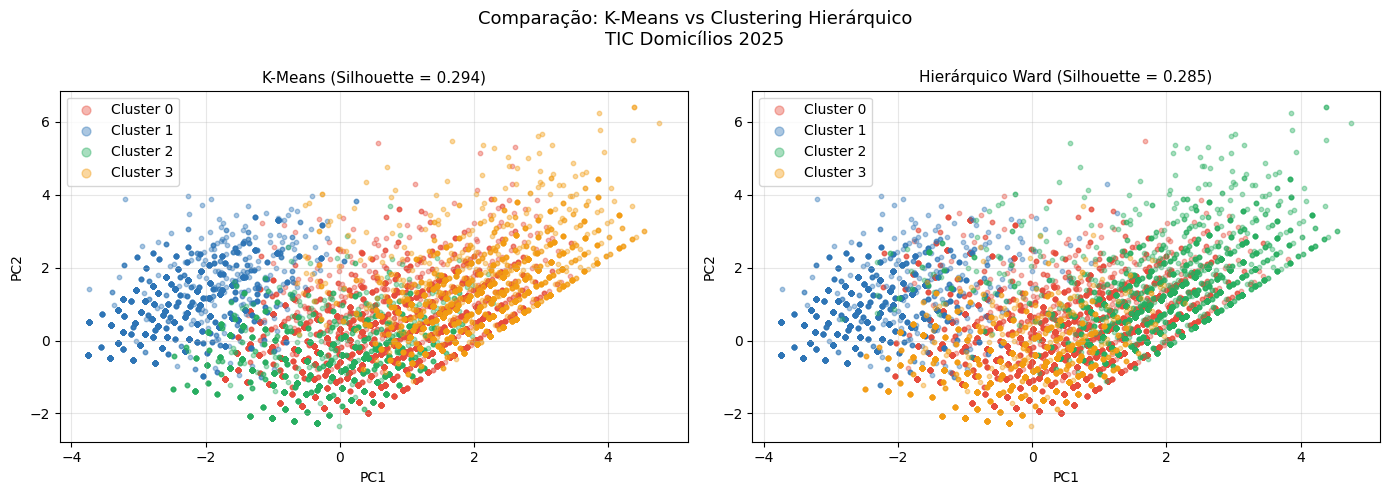

✅ Comparação salva!


In [4]:
# ════════════════════════════════════════════════════
# CLUSTERING HIERÁRQUICO — base completa
# ════════════════════════════════════════════════════
hc = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels_hc = hc.fit_predict(X)

score_hc = silhouette_score(X, labels_hc)
print(f'Silhouette Score — Hierárquico: {score_hc:.3f}')
print(f'Silhouette Score — K-Means:     0.294')
print(f'\nDiferença: {abs(score_hc - 0.294):.3f}')

print('\nTamanho dos clusters (Hierárquico):')
import pandas as pd
print(pd.Series(labels_hc).value_counts().sort_index())

# Perfil médio
df_model['cluster_hc'] = labels_hc
print('\nPerfil médio por cluster (Hierárquico):')
print(df_model.groupby('cluster_hc')[
    ['tem_tv','tem_radio','tem_internet',
     'usa_celular_net','renda','escolaridade','area']
].mean().round(2))

# Visualização PCA — comparação lado a lado
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

cores = ['#E74C3C','#2E75B6','#27AE60','#F39C12']

# K-Means
labels_km = df_model['cluster'].values
for i in range(4):
    mask = labels_km == i
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=cores[i], alpha=0.4, s=10,
                label=f'Cluster {i}')
ax1.set_title(f'K-Means (Silhouette = 0.294)', fontsize=11)
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.legend(markerscale=2)
ax1.grid(alpha=0.3)

# Hierárquico
for i in range(4):
    mask = labels_hc == i
    ax2.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=cores[i], alpha=0.4, s=10,
                label=f'Cluster {i}')
ax2.set_title(f'Hierárquico Ward (Silhouette = {score_hc:.3f})', fontsize=11)
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.legend(markerscale=2)
ax2.grid(alpha=0.3)

plt.suptitle('Comparação: K-Means vs Clustering Hierárquico\nTIC Domicílios 2025', fontsize=13)
plt.tight_layout()
plt.savefig('graficos/comparacao_kmeans_hierarquico.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Comparação salva!')

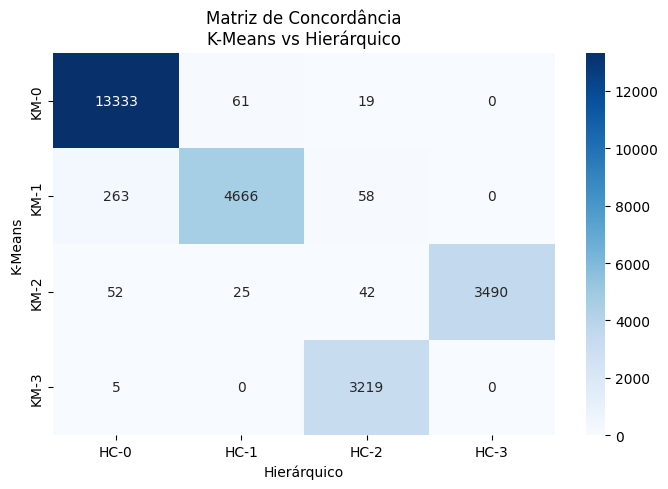

In [5]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(labels_km, labels_hc)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['HC-0','HC-1','HC-2','HC-3'],
            yticklabels=['KM-0','KM-1','KM-2','KM-3'])
plt.title('Matriz de Concordância\nK-Means vs Hierárquico')
plt.xlabel('Hierárquico')
plt.ylabel('K-Means')
plt.tight_layout()
plt.savefig('graficos/matriz_concordancia.png', dpi=150, bbox_inches='tight')
plt.show()